In [4]:
import sys
!{sys.executable} -m pip install google-api-python-client pandas

  Using cached uritemplate-4.2.0-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
    --------------------------------------- 0.3/15.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/15.6 MB 2.6 MB/s eta 0:00:06
   ---- ----------------------------------- 1.6/15.6 MB 3.1 MB/s eta 0:00:05
   ---- ----------------------------------- 1.8/15.6 MB 2.8 MB/s eta 0:00:06
   ------ --------------------------------- 2.4/15.6 MB 2.5 MB/s eta 0:00:06
   ------ --------------------------------- 2.6/15.6 MB 2.7 MB/s eta 0:00:05
   -------- ------------------------------- 3.4/15.6 MB 2.7 MB/s eta 0:00:05
   ---------- ----------------------------- 3.9/15.6 MB 2.6 MB/s eta 0:00:05
   ----------- ---------------------------- 4.5/15.6 MB 2.5 MB/s eta 0:00:05
   ------------ --------------------------- 5.0/15.6 MB 2.5 MB/s eta 0:00:05
   ------------- -------------------------- 5.2/15.6 MB 2.4 MB/s eta 0:00:05
   -------------- ----

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [ ]:
from googleapiclient.discovery import build
import pandas as pd

API_KEY  = "os.getenv("YOUTUBE_API_KEY")"
VIDEO_ID = "eHTXQW58WhA"

youtube = build("youtube", "v3", developerKey=API_KEY)

def fetch_all_comments(video_id, max_comments=10000):
    comments = []
    request = youtube.commentThreads().list(
        part       = "snippet",
        videoId    = video_id,
        maxResults = 100,
        textFormat = "plainText",
        order      = "relevance"
    )

    while request:
        response = request.execute()

        for item in response["items"]:
            snippet = item["snippet"]["topLevelComment"]["snippet"]
            comments.append({
                "comment_id"  : item["id"],
                "author"      : snippet["authorDisplayName"],
                "comment"     : snippet["textDisplay"],
                "likes"       : snippet["likeCount"],
                "date"        : snippet["publishedAt"],
                "reply_count" : item["snippet"]["totalReplyCount"]
            })

        print(f"{len(comments)} comments collected...", end="\r")

        # STOP if we hit our limit
        if len(comments) >= max_comments:
            print(f"\nReached limit of {max_comments}. Stopping.")
            break

        # STOP if no next page exists
        if "nextPageToken" not in response:
            print(f"\nAll comments fetched! Total: {len(comments)}")
            break

        request = youtube.commentThreads().list(
            part          = "snippet",
            videoId       = video_id,
            maxResults    = 100,
            textFormat    = "plainText",
            order         = "relevance",
            pageToken     = response["nextPageToken"]
        )

    return comments

data = fetch_all_comments(VIDEO_ID, max_comments=10000)
df   = pd.DataFrame(data)

print(f"Total: {len(df)} comments")
df.head()

1244 comments collected...
All comments fetched! Total: 1244
Total: 1244 comments


,comment_id,author,comment,likes,date,reply_count
0,Ugz8ViMW-1VEeFHXXSh4AaABAg,@AvinashtheAgarwalOfficial,"This is Avinash Agarwal, Thank you so much Sam...",1572,2026-06-28T14:24:39Z,48
1,UgzmNvev5M_79rJiMjx4AaABAg,@ashishsolanki_1,Mai police ki taraf se hi aaya tha.,237028,2026-06-20T15:01:01Z,1000
2,UgzJ5Z3NgeZDqgyIi9V4AaABAg,@FootnBallzz,That Drunk guy lowkey gave me goosebumps when ...,72292,2026-06-20T14:43:29Z,185
3,UgxbsxSyXyGEXyWQ-SN4AaABAg,@anjankumar8687,Lagta he pehle episode se hi kaand ho gaya,17,2026-06-28T13:39:16Z,0
4,UgzgzpzaEpMYxvHd73p4AaABAg,@Vlogopinion0102,First ever hit show jiska channel pe season 1 ...,55227,2026-06-20T17:48:02Z,111


In [9]:
def fetch_replies(parent_id):
    replies = []
    request = youtube.comments().list(
        part      = "snippet",
        parentId  = parent_id,
        maxResults= 100,
        textFormat= "plainText"
    )
    while request:
        response = request.execute()
        for item in response["items"]:
            s = item["snippet"]
            replies.append({
                "comment_id"  : item["id"],
                "author"      : s["authorDisplayName"],
                "comment"     : s["textDisplay"],
                "likes"       : s["likeCount"],
                "date"        : s["publishedAt"],
                "reply_count" : 0
            })
        if "nextPageToken" not in response:
            break
        request = youtube.comments().list(
            part      = "snippet",
            parentId  = parent_id,
            maxResults= 100,
            textFormat= "plainText",
            pageToken = response["nextPageToken"]
        )
    return replies

# Fetch replies for comments that have them
all_data = df.to_dict("records")   # keep original comments
total    = len(df[df["reply_count"] > 0])
done     = 0

for _, row in df[df["reply_count"] > 0].iterrows():
    replies   = fetch_replies(row["comment_id"])
    all_data += replies
    done     += 1
    print(f"Fetching replies... {done}/{total} threads done — {len(all_data)} total comments", end="\r")

    if len(all_data) >= 10000:
        print(f"\nReached 10,000! Stopping.")
        break

df_full = pd.DataFrame(all_data)
print(f"\nFinal total: {len(df_full)} comments")
df_full.to_csv("raw_comments.csv", index=False)
print("Saved to raw_comments.csv")
df_full.head()

Fetching replies... 297/297 threads done — 5839 total comments
Final total: 5839 comments
Saved to raw_comments.csv


,comment_id,author,comment,likes,date,reply_count
0,Ugz8ViMW-1VEeFHXXSh4AaABAg,@AvinashtheAgarwalOfficial,"This is Avinash Agarwal, Thank you so much Sam...",1572,2026-06-28T14:24:39Z,48
1,UgzmNvev5M_79rJiMjx4AaABAg,@ashishsolanki_1,Mai police ki taraf se hi aaya tha.,237028,2026-06-20T15:01:01Z,1000
2,UgzJ5Z3NgeZDqgyIi9V4AaABAg,@FootnBallzz,That Drunk guy lowkey gave me goosebumps when ...,72292,2026-06-20T14:43:29Z,185
3,UgxbsxSyXyGEXyWQ-SN4AaABAg,@anjankumar8687,Lagta he pehle episode se hi kaand ho gaya,17,2026-06-28T13:39:16Z,0
4,UgzgzpzaEpMYxvHd73p4AaABAg,@Vlogopinion0102,First ever hit show jiska channel pe season 1 ...,55227,2026-06-20T17:48:02Z,111


In [10]:
import pandas as pd

df = pd.read_csv("raw_comments.csv")
print(f"Total comments: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()

Total comments: 5839
Columns: ['comment_id', 'author', 'comment', 'likes', 'date', 'reply_count']

Missing values:
comment_id     0
author         0
comment        4
likes          0
date           0
reply_count    0
dtype: int64


,comment_id,author,comment,likes,date,reply_count
0,Ugz8ViMW-1VEeFHXXSh4AaABAg,@AvinashtheAgarwalOfficial,"This is Avinash Agarwal, Thank you so much Sam...",1572,2026-06-28T14:24:39Z,48
1,UgzmNvev5M_79rJiMjx4AaABAg,@ashishsolanki_1,Mai police ki taraf se hi aaya tha.,237028,2026-06-20T15:01:01Z,1000
2,UgzJ5Z3NgeZDqgyIi9V4AaABAg,@FootnBallzz,That Drunk guy lowkey gave me goosebumps when ...,72292,2026-06-20T14:43:29Z,185
3,UgxbsxSyXyGEXyWQ-SN4AaABAg,@anjankumar8687,Lagta he pehle episode se hi kaand ho gaya,17,2026-06-28T13:39:16Z,0
4,UgzgzpzaEpMYxvHd73p4AaABAg,@Vlogopinion0102,First ever hit show jiska channel pe season 1 ...,55227,2026-06-20T17:48:02Z,111


In [11]:
import re

def clean_comment(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)           # remove URLs
    text = re.sub(r"@\w+", "", text)              # remove @mentions
    text = re.sub(r"[^\w\s,.!?']", " ", text)     # remove emojis/symbols
    text = re.sub(r"\s+", " ", text).strip()      # remove extra spaces
    return text

df.drop_duplicates(subset=["comment"], inplace=True)   # remove duplicate comments
df.dropna(subset=["comment"], inplace=True)            # remove empty rows
df["comment_clean"] = df["comment"].apply(clean_comment)
df = df[df["comment_clean"].str.len() > 5]            # remove very short comments

print(f"After cleaning: {len(df)} comments remaining")
df[["comment", "comment_clean"]].head(5)

After cleaning: 4502 comments remaining


,comment,comment_clean
0,"This is Avinash Agarwal, Thank you so much Sam...","This is Avinash Agarwal, Thank you so much Sam..."
1,Mai police ki taraf se hi aaya tha.,Mai police ki taraf se hi aaya tha.
2,That Drunk guy lowkey gave me goosebumps when ...,That Drunk guy lowkey gave me goosebumps when ...
3,Lagta he pehle episode se hi kaand ho gaya,Lagta he pehle episode se hi kaand ho gaya
4,First ever hit show jiska channel pe season 1 ...,First ever hit show jiska channel pe season 1 ...


In [26]:
# All performers/guests who appear on India Got Latent
performers = [
    "Samay", "Tanmay", "Zakir", "Biswa", "Ashish",
    "Carry", "CarryMinati", "Elvish", "Ranveer", "Virat",
    "Rohit", "Abhishek", "Avinash","Sharvari","Alia","Donald Trump","Drunk guy","Sagar", "Apoorva","Balraj","sukhrudev","Trump","Kashmiri"
    "Munawar", "Raftaar", "Badshah", "Bhuvan", "Triggered"
]

# Count how many comments mention each performer
mention_counts = {}
for performer in performers:
    count = df["comment_clean"].str.contains(
        performer, case=False, na=False
    ).sum()
    if count > 0:
        mention_counts[performer] = count

# Sort by most mentioned
mention_df = pd.DataFrame(
    list(mention_counts.items()),
    columns=["Performer", "Mentions"]
).sort_values("Mentions", ascending=False)

print("=" * 40)
print("PERFORMER MENTION LEADERBOARD")
print("=" * 40)
print(mention_df.to_string(index=False))
print(f"\nMost mentioned performer: {mention_df.iloc[0]['Performer']}")
print(f"Total mentions: {mention_df.iloc[0]['Mentions']}")


PERFORMER MENTION LEADERBOARD
   Performer  Mentions
       Trump       301
       Samay       277
        Alia       219
Donald Trump       100
      Ashish        73
    Sharvari        69
     Ranveer        41
      Balraj        36
   Drunk guy        21
     Avinash        11
      Tanmay         4
       Carry         4
      Elvish         3
    Abhishek         3
   Triggered         2
       Biswa         1
   sukhrudev         1
      Bhuvan         1

Most mentioned performer: Trump
Total mentions: 301


In [27]:
# Which performer's mentions get the most likes
def avg_likes_for_performer(name):
    mask = df["comment_clean"].str.contains(name, case=False, na=False)
    return df[mask]["likes"].mean()

mention_df["Avg_Likes_On_Mentions"] = mention_df["Performer"].apply(
    avg_likes_for_performer
)
mention_df["Avg_Likes_On_Mentions"] = mention_df["Avg_Likes_On_Mentions"].round(1)

print("\n" + "=" * 50)
print("PERFORMER ENGAGEMENT SCORE")
print("=" * 50)
print(mention_df.to_string(index=False))


PERFORMER ENGAGEMENT SCORE
   Performer  Mentions  Avg_Likes_On_Mentions
       Trump       301                 1071.9
       Samay       277                  288.7
        Alia       219                  193.2
Donald Trump       100                 1215.7
      Ashish        73                  167.6
    Sharvari        69                  262.5
     Ranveer        41                  326.2
      Balraj        36                 1176.4
   Drunk guy        21                 4222.6
     Avinash        11                  145.4
      Tanmay         4                   24.0
       Carry         4                  258.5
      Elvish         3                    0.0
    Abhishek         3                  145.3
   Triggered         2                    0.0
       Biswa         1                    0.0
   sukhrudev         1                    2.0
      Bhuvan         1                    7.0


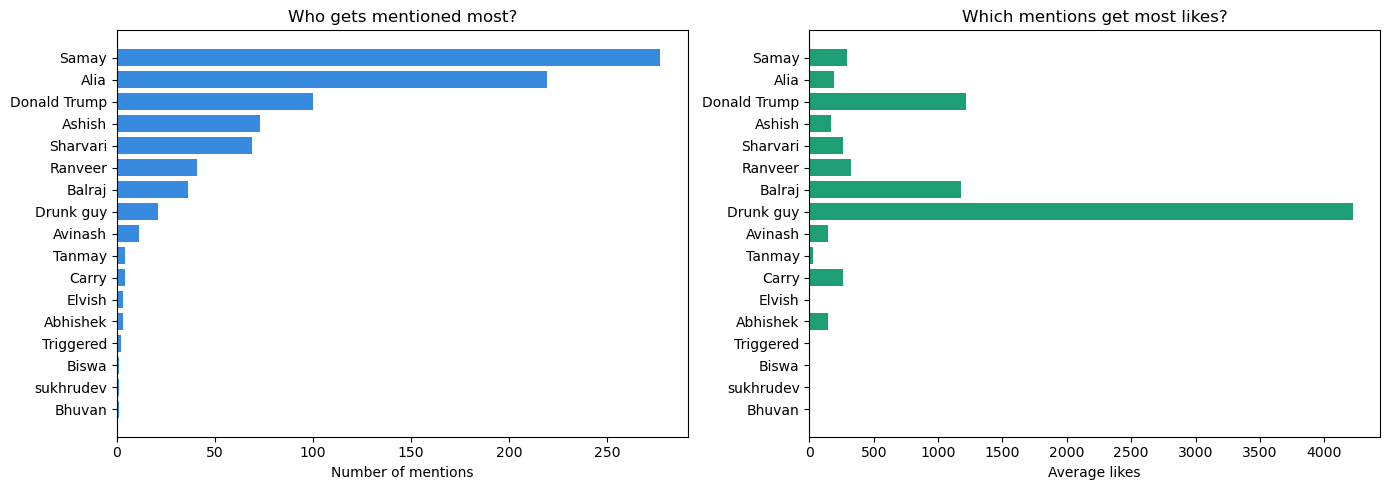

Chart saved as performer_analysis.png


In [21]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - mention count
ax1.barh(mention_df["Performer"], mention_df["Mentions"], color="#378ADD")
ax1.set_title("Who gets mentioned most?")
ax1.set_xlabel("Number of mentions")
ax1.invert_yaxis()

# Chart 2 - avg likes on those mentions
ax2.barh(mention_df["Performer"], mention_df["Avg_Likes_On_Mentions"], color="#1D9E75")
ax2.set_title("Which mentions get most likes?")
ax2.set_xlabel("Average likes")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()
print("Chart saved as performer_analysis.png")

In [22]:
import sys
!{sys.executable} -m pip install mysql-connector-python sqlalchemy pymysql

   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
    --------------------------------------- 0.3/17.7 MB ? eta -:--:--
    --------------------------------------- 0.3/17.7 MB ? eta -:--:--
    --------------------------------------- 0.3/17.7 MB ? eta -:--:--
   - -------------------------------------- 0.5/17.7 MB 387.2 kB/s eta 0:00:45
   - -------------------------------------- 0.5/17.7 MB 387.2 kB/s eta 0:00:45
   - -------------------------------------- 0.5/17.7 MB 387.2 kB/s eta 0:00:45
   - -------------------------------------- 0.8/17.7 MB 425.6 kB/s eta 0:00:40
   - -------------------------------------- 0.8/17.7 M

In [23]:
import sys
!{sys.executable} -m pip install pyodbc sqlalchemy

In [24]:
import pyodbc
from sqlalchemy import create_engine
import pandas as pd
import urllib

# ---- YOUR SSMS DETAILS ----
SERVER   = "localhost\SQLEXPRESS"   # paste your server name here
DATABASE = "youtube_analysis"
# ---------------------------

# Connection string for Windows Authentication
# (no username/password needed if using Windows login)
params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"        # uses your Windows login automatically
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# Store cleaned dataframe into SQL Server
df.to_sql(
    name      = "comments",
    con       = engine,
    if_exists = "replace",
    index     = False
)

print(f"Done! {len(df)} rows saved into SQL Server!")

C:\Users\jaybh\anaconda3\Lib\site-packages\pandas\io\sql.py:1636: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


Done! 4502 rows saved into SQL Server!


In [28]:
query = """
SELECT 
    CASE 
        WHEN comment_clean LIKE '%Samay%'     THEN 'Samay'
        WHEN comment_clean LIKE '%Tanmay%'    THEN 'Tanmay'
        WHEN comment_clean LIKE '%Ashish%'    THEN 'Ashish'
        WHEN comment_clean LIKE '%Elvish%'    THEN 'Elvish'
        WHEN comment_clean LIKE '%Carry%'     THEN 'CarryMinati'
        WHEN comment_clean LIKE '%Zakir%'     THEN 'Zakir'
        WHEN comment_clean LIKE '%Biswa%'     THEN 'Biswa'
        WHEN comment_clean LIKE '%Bhuvan%'    THEN 'Bhuvan Bam'
        WHEN comment_clean LIKE '%Munawar%'   THEN 'Munawar'
        WHEN comment_clean LIKE '%Triggered%' THEN 'Triggered Insaan'
        WHEN comment_clean LIKE '%Donald Trump%' THEN 'Donald  Trump'
        WHEN comment_clean LIKE '%Trump%' THEN 'Trump'
        ELSE 'Others'
    END AS performer,
    COUNT(*)         AS total_mentions,
    AVG(likes)       AS avg_likes,
    MAX(likes)       AS max_likes,
    SUM(reply_count) AS total_replies
FROM comments
WHERE comment_clean IS NOT NULL
GROUP BY 
    CASE 
        WHEN comment_clean LIKE '%Samay%'     THEN 'Samay'
        WHEN comment_clean LIKE '%Tanmay%'    THEN 'Tanmay'
        WHEN comment_clean LIKE '%Ashish%'    THEN 'Ashish'
        WHEN comment_clean LIKE '%Elvish%'    THEN 'Elvish'
        WHEN comment_clean LIKE '%Carry%'     THEN 'CarryMinati'
        WHEN comment_clean LIKE '%Zakir%'     THEN 'Zakir'
        WHEN comment_clean LIKE '%Biswa%'     THEN 'Biswa'
        WHEN comment_clean LIKE '%Bhuvan%'    THEN 'Bhuvan Bam'
        WHEN comment_clean LIKE '%Munawar%'   THEN 'Munawar'
        WHEN comment_clean LIKE '%Triggered%' THEN 'Triggered Insaan'
        WHEN comment_clean LIKE '%Donald Trump%' THEN 'Donald  Trump'
        WHEN comment_clean LIKE '%Trump%' THEN 'Trump'
        ELSE 'Others'
    END
ORDER BY total_mentions DESC;
"""

result = pd.read_sql(query, engine)
print("=" * 60)
print("PERFORMER LEADERBOARD FROM SQL SERVER")
print("=" * 60)
print(result.to_string(index=False))

PERFORMER LEADERBOARD FROM SQL SERVER
       performer  total_mentions  avg_likes  max_likes  total_replies
          Others            3869        209     237028           3375
           Samay             277        288      47489            354
           Trump             190        803      76502            538
   Donald  Trump              89       1283      51517            305
          Ashish              64         88       3494             18
     CarryMinati               4        258       1017              5
          Tanmay               4         24         76              0
Triggered Insaan               2          0          0              0
          Elvish               2          0          0              0
           Biswa               1          0          0              0
